In [7]:
import os
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn as nn
from torchvision.transforms import v2 as transforms
import librosa
import numpy as np
from sklearn.metrics import roc_auc_score, mean_squared_error
import matplotlib.pyplot as plt

In [2]:
generator = torch.Generator().manual_seed(42)
np.random.seed(42)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
])

crop = transforms.RandomCrop(size=(128, 512))


class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, audio_dir, train):
        self.audio_dir = audio_dir
        file_list = os.listdir(audio_dir)

        labels = np.zeros(len(file_list), dtype=int) if train else [1 if el[0] == 'a' else 0 for el in file_list]
        self.labels = torch.tensor(labels, dtype=torch.int8).to(device)

        loads = [torchaudio.load(os.path.join(audio_dir, el)) for el in file_list]
        spectrograms = [T.MelSpectrogram(sr, n_fft=624)(audio) for audio, sr in loads]
        spect_dbs = [
            T.AmplitudeToDB(stype='power')(spec)
            for spec in spectrograms
        ]

        spect_dbs = torch.stack(spect_dbs)

        mean = spect_dbs.mean(dim=0)
        std = spect_dbs.std(dim=0)

        self.spect_dbs = (spect_dbs - mean) / std

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return crop(self.spect_dbs[idx]), self.labels[idx]

In [5]:
train_dataset = AudioDataset('archive/dev_data/dev_data/slider/train', train=True)
test_dataset = AudioDataset('archive/dev_data/dev_data/slider/test', train=False)

In [ ]:
batch_size = 16

train_set, validation_set = torch.utils.data.random_split(train_dataset, [0.8, 0.2], generator=generator)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True
)
validation_loader = torch.utils.data.DataLoader(
    validation_set,
    batch_size=batch_size,
    shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
class CNNAE(nn.Module):
    def __init__(self):
        super(CNNAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),   # (32, 128, 256)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # (32, 64, 128)
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # (64, 64, 128)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # (64, 32, 64)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # (128, 32, 64)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # (128, 16, 32)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),   # (64, 32, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),    # (32, 64, 128)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),     # (1, 128, 256)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.squeeze(1)


class C1DNNAE(nn.Module):
    def __init__(self):
        super(C1DNNAE, self).__init__()
        # Encoder: input shape (batch, 128, 256)
        self.encoder = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=5, stride=2, padding=2),   # (batch, 64, 128)
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=5, stride=2, padding=2),    # (batch, 32, 64)
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=5, stride=2, padding=2),    # (batch, 16, 32)
            nn.ReLU(),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 32, kernel_size=4, stride=2, padding=1),  # (batch, 32, 64)
            nn.ReLU(),
            nn.ConvTranspose1d(32, 64, kernel_size=4, stride=2, padding=1),  # (batch, 64, 128)
            nn.ReLU(),
            nn.ConvTranspose1d(64, 128, kernel_size=4, stride=2, padding=1),  # (batch, 128, 256)
        )

    def forward(self, x):
        # x: (batch, 128, 256) expected
        x = self.encoder(x)
        x = self.decoder(x)
        return x


class C1DNNAE_INV(nn.Module):
    def __init__(self):
        super(C1DNNAE_INV, self).__init__()
        # Encoder: input shape (batch, 256, 128)
        self.encoder = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=5, stride=2, padding=2),   # (batch, 128, 64)
            nn.ReLU(),
            nn.Conv1d(128, 64, kernel_size=5, stride=2, padding=2),    # (batch, 64, 32)
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=5, stride=2, padding=2),     # (batch, 32, 16)
            nn.ReLU(),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 64, kernel_size=4, stride=2, padding=1),   # (batch, 64, 32)
            nn.ReLU(),
            nn.ConvTranspose1d(64, 128, kernel_size=4, stride=2, padding=1),  # (batch, 128, 64)
            nn.ReLU(),
            nn.ConvTranspose1d(128, 256, kernel_size=4, stride=2, padding=1),  # (batch, 256, 128)
        )

    def forward(self, x):
        # x: (batch, 128, 256) expected
        x = x.permute(0, 2, 1)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.permute(0, 2, 1)


class LAE(nn.Module):
    def __init__(self):
        super(LAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(128 * 256, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        self.decoder = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2048),
            nn.ReLU(),
            nn.Linear(2048, 128 * 256),
            # nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(x.size(0), 128, 256)

In [ ]:
def train_one_epoch(model, data_loader, optimizer, criterion):
    model.train()

    total_loss = 0

    for inputs, _ in data_loader:
        inputs = inputs.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        # print(inputs.shape)
        # print(outputs.shape)

        loss = criterion(outputs, inputs)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)


def validate(model, data_loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            total_loss += loss.item()

    return total_loss / len(data_loader)


def compute_reconstruction_errors(model, data_loader):
    model.eval()
    errors = []
    with torch.no_grad():
        for batch, _ in data_loader:
            batch = batch.to(device)
            reconstructed = model(batch)
            # print(reconstructed.shape, batch.shape)
            error = torch.mean(((reconstructed - batch) ** 2).reshape(batch.size(0), -1), dim=1)
            # print(error.shape)
            errors.extend(error.cpu().numpy())
    return errors


def test(model, data_loader):
    model.eval()

    errors = compute_reconstruction_errors(model, data_loader)

    roc_auc_scores = roc_auc_score(test_dataset.labels.cpu(), errors)
    print(f"ROC AUC Score test: {roc_auc_scores}")

    return roc_auc_scores

In [ ]:
def train(lr, weight_decay, epochs):
    model = LAE().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = validate(model, validation_loader, criterion)
        test(model, test_loader)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

    return model

In [ ]:
train_dataset.spect_dbs.shape, test_dataset.spect_dbs.shape

In [ ]:
class VAE(nn.Module):

    def __init__(self, input_dim=128 * 512, hidden_dim=512, latent_dim=256):
        super(VAE, self).__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2)
        )

        # latent mean and variance
        self.mean_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh()
        )

    def encode(self, x):
        x = self.encoder(x)
        return self.mean_layer(x), self.logvar_layer(x)

    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(device)
        return mean + var * epsilon

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, torch.exp(0.5 * logvar))
        x_hat = self.decode(z)
        return x_hat, mean, logvar


def loss_function_vae(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.cross_entropy(x_hat, x, reduction='sum')
    KLD = - 0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD


def train_one_epoch_vae(model, data_loader, optimizer):
    model.train()

    total_loss = 0

    for inputs, _ in data_loader:
        inputs = inputs.to(device)
        inputs = inputs.view(inputs.size(0), -1)  # Flatten the input

        optimizer.zero_grad()

        x_hat, mean, logvar = model(inputs)
        loss = loss_function_vae(inputs, x_hat, mean, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)


def validate_vae(model, data_loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            inputs = inputs.view(inputs.size(0), -1)
            x_hat, mean, logvar = model(inputs)
            loss = loss_function_vae(inputs, x_hat, mean, logvar)
            total_loss += loss.item()

    return total_loss / len(data_loader)


def compute_reconstruction_errors_vae(model, data_loader):
    model.eval()
    errors = []
    with torch.no_grad():
        for batch, _ in data_loader:
            batch = batch.to(device)
            batch = batch.view(batch.size(0), -1)
            reconstructed, _, _ = model(batch)
            # print(reconstructed.shape, batch.shape)
            error = torch.mean(((reconstructed - batch) ** 2).reshape(batch.size(0), -1), dim=1)
            # print(error.shape)
            errors.extend(error.cpu().numpy())
    return errors


def test_vae(model, data_loader):
    model.eval()

    errors = compute_reconstruction_errors_vae(model, data_loader)

    roc_auc_scores = roc_auc_score(test_dataset.labels.cpu(), errors)
    return roc_auc_scores


def train_vae(lr, weight_decay, epochs):
    model = VAE().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(epochs):
        train_loss = train_one_epoch_vae(model, train_loader, optimizer)
        val_loss = validate_vae(model, validation_loader)
        test_roc_auc = test_vae(model, test_loader)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Test ROC AUC: {test_roc_auc:.4f}")

    return model

In [ ]:
model = train_vae(lr=1e-3, weight_decay=1e-8, epochs=50)

In [ ]:
# path = 'archive/dev_data/dev_data/slider/train'

# loads = [librosa.load(os.path.join(path, el), sr=None) for el in os.listdir(path)]
# print("Loaded")
# spectrograms = [librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128) for audio, sr in loads]
# print("Spectrograms")
# not_flat = [
#     torch.tensor(
#         librosa.power_to_db(spec, ref=np.max),
#         dtype=torch.float32
#     )
#     for spec in spectrograms
# ]
# spect_dbs_not_flat = torch.stack(not_flat).to(device)

# flat = [
#     torch.tensor(
#         librosa.power_to_db(spec, ref=np.max),
#         dtype=torch.float32
#     ).flatten()
#     for spec in spectrograms
# ]
# spect_dbs_flat = torch.stack(flat).to(device)

In [ ]:
# mean_flat = torch.mean(spect_dbs_flat, dim=0)
# std_flat = torch.std(spect_dbs_flat, dim=0)

# end_flat = (spect_dbs_flat - mean_flat) / std_flat

In [ ]:
# mean_not_flat = torch.mean(spect_dbs_not_flat, dim=0)
# std_not_flat = torch.std(spect_dbs_not_flat, dim=0)
# end_not_flat = (spect_dbs_not_flat - mean_not_flat) / std_not_flat
# end2 = end_not_flat.flatten(start_dim=1)

In [ ]:
# torch.allclose(end_flat, end2)

In [ ]:
# spect_dbs_not_flat.shape

In [14]:
train_dataset.spect_dbs.shape, test_dataset.spect_dbs.shape

(torch.Size([2370, 1, 128, 513]), torch.Size([1101, 1, 128, 513]))

In [ ]:
x = np.random.rand(1000) * 10
y = x / np.linalg.norm(x)
y.max(), y.min()

In [8]:
from IPython.display import Audio
from matplotlib.patches import Rectangle


def plot_waveform(waveform, sr, title="Waveform", ax=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sr

    if ax is None:
        _, ax = plt.subplots(num_channels, 1)
    ax.plot(time_axis, waveform[0], linewidth=1)
    ax.grid(True)
    ax.set_xlim([0, time_axis[-1]])
    ax.set_title(title)


def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")


def plot_fbank(fbank, title=None):
    fig, axs = plt.subplots(1, 1)
    axs.set_title(title or "Filter bank")
    axs.imshow(fbank, aspect="auto")
    axs.set_ylabel("frequency bin")
    axs.set_xlabel("mel bin")

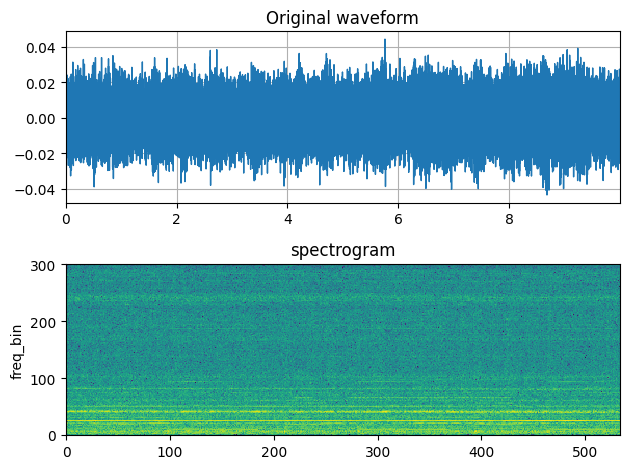

In [13]:
SAMPLE_SPEECH = 'archive/dev_data/dev_data/slider/train/normal_id_00_00000107.wav'
SPEECH_WAVEFORM, SAMPLE_RATE = torchaudio.load(SAMPLE_SPEECH)
spectrogram = T.Spectrogram(n_fft=600)
spec = spectrogram(SPEECH_WAVEFORM)
fig, axs = plt.subplots(2, 1)
plot_waveform(SPEECH_WAVEFORM, SAMPLE_RATE, title="Original waveform", ax=axs[0])
plot_spectrogram(spec[0], title="spectrogram", ax=axs[1])
fig.tight_layout()